# Validation & Benchmark: emcee vs Rejection Sampling

**Objetivo:** Diagnosticar por qué los posteriores de `mcra-planet-b_emcee.ipynb` no coinciden con los de `Zuluaga_PhotoRing/mcra-planet-b.ipynb` y validar la implementación.

## Tests incluidos

1. **Test 1** — Equivalencia de la verosimilitud
2. **Test 2** — Diagnóstico de la fórmula de `nsteps`
3. **Test 3** — Comparación en un solo punto de la grilla (rejection vs emcee)
4. **Test 4** — Diagnósticos de convergencia
5. **Test 5** — Test KS de las distribuciones marginales

## Setup

In [10]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('./dependencies')
sys.path.append('../../Zuluaga_PhotoRing/GeoTrans')

from geotrans2 import *
from emcee_utils import (
    log_prior, log_likelihood, log_probability,
    make_log_prob_func, initialize_walkers,
    convergence_summary
)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import pickle
from scipy.stats import norm, multivariate_normal, ks_2samp
import warnings
import multiprocess as mp
import time
from copy import deepcopy
import emcee
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

import os
N_CPUS = os.cpu_count()
n_processes = max(1, N_CPUS - 1)
print(f'CPUs available: {N_CPUS}, using: {n_processes}')
print('Setup OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPUs available: 8, using: 7
Setup OK


## Initialize System (identical to both notebooks)

In [11]:
# ---- Density functions ----
with open('dependencies/rho_true_fun.pkl', 'rb') as f:
    rho_true_fun = pickle.load(f)
with open('dependencies/rho_obs_b_fun.pkl', 'rb') as f:
    rho_obs_b_fun = pickle.load(f)

rho_obs_fun = rho_obs_b_fun

# ---- Stellar parameters ----
df_cat = pd.read_csv('dependencies/Kepler_51_Kipping/GKTHCatalog_Table4.csv')
k51 = df_cat[df_cat['id_starname'] == 'kic11773022']

M_mean = k51.iso_mass.values[0]
R_mean = k51.iso_rad.values[0]
M_std = (k51.iso_mass_err1.values[0] + abs(k51.iso_mass_err2.values[0])) / 2
R_std = (k51.iso_rad_err1.values[0] + abs(k51.iso_rad_err2.values[0])) / 2

Ms_mean, Ms_std = M_mean * MSUN, M_std * MSUN
Rs_mean, Rs_std = R_mean * RSUN, R_std * RSUN

# ---- Planet parameters (Kepler-51b, Masuda et al. 2024) ----
Rp_mean = 0.609 * RJUP
Rp_std = 0.012 * RJUP
Porb_mean = 45.15405 * DAY
Porb_std = 0.00039 * DAY
borb_mean = 0.0740
borb_std = 0.0720
Mp_mean = 0.011 * MJUP
Mp_std = 0.007 * MJUP

# ---- Derived quantities ----
delta_mean = (Rp_mean / Rs_mean) ** 2
delta_std = 2 * delta_mean * (Rp_std / Rp_mean + Rs_std / Rs_mean)
ap_mean = ((GCONST * Ms_mean * Porb_mean ** 2) / (4 * pi ** 2)) ** (1 / 3)
iorb_mean = np.arccos(borb_mean * Rs_mean / ap_mean) * RAD
Rp_min = REARTH * (Mp_mean / MEARTH) ** (1 / 3)
fRp_min = Rp_min / Rp_mean

# ---- Build system ----
System = RingedSystem(
    system=dict(
            Mstar=Ms_mean, Rstar=Rs_mean,
            Rplanet=Rp_mean, Mplanet=Mp_mean,
            ap=ap_mean, iorb=iorb_mean * DEG,
            fe=1, fi=1, ir=0.0 * DEG, phir=0.0 * DEG, tau=1.0,
    )
)
System.noauto = True
System.Porb_mean = Porb_mean
System.borb_mean = borb_mean
System.delta_mean = delta_mean
System.delta_std = delta_std
System.delta_fun = lambda x: norm.pdf(x, delta_mean, delta_std)
System.rho_obs_fun = rho_obs_fun
System.rho_true_fun = rho_true_fun

# ---- Adjustment function ----
def adjust_params(S, verbose=False):
    S.ap = ((GCONST * S.Mstar * S.Porb_mean ** 2) / (4 * pi ** 2)) ** (1 / 3)
    S.iorb = np.arccos(S.borb_mean * S.Rstar / S.ap)
    S.updateSystem()

# ---- Parameter space ----
props = dict(
    fe=dict(label=r'$f_e$', range=[1.1, 6.0], scale=1),
    Rplanet=dict(label=r'$R_p$ [$R_{jup}$]',
                     range=[fRp_min * Rp_mean / RJUP, Rp_mean / RJUP], scale=RJUP),
    ir=dict(label=r'$i_r$ [deg]', range=[0.0, 90.0], scale=DEG),
    phir=dict(label=r'$\phi_r$ [deg]', range=[0.0, 90.0], scale=DEG),
)

store_params = dict(
    rho_true=dict(prop='rho_true', scale=1),
    rho_obs=dict(prop='rho_obs', scale=1),
    PR=dict(prop='PR', scale=1),
    ieff=dict(prop='ieff', scale=RAD),
    teff=dict(prop='teff', scale=RAD),
    delta=dict(prop='Ar', scale=1 / np.pi),
)

ndim = len(props)

# ---- Stellar grid ----
Ng = 5
ts = 2
MS, RS = np.meshgrid(
    np.linspace(Ms_mean - ts * Ms_std, Ms_mean + ts * Ms_std, Ng) / MSUN,
    np.linspace(Rs_mean - ts * Rs_std, Rs_mean + ts * Rs_std, Ng) / RSUN
)
delta_Ms = MS[0, 1] - MS[0, 0]
delta_Rs = RS[1, 0] - RS[0, 0]

rho_MR = -0.2
cov = [[M_std ** 2, rho_MR * M_std * R_std],
       [rho_MR * M_std * R_std, R_std ** 2]]
PS = np.zeros(MS.shape)
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
            PS[i, j] = multivariate_normal.pdf([MS[i, j], RS[i, j]],
                                               mean=[M_mean, R_mean], cov=cov)
PS *= delta_Ms * delta_Rs

# ---- Rejection sampling function (single worker) ----
def mcra_grid_general(S, props, store, adjust, Np, seed=None):
    noauto = S.noauto
    S.noauto = True
    if seed is not None:
        np.random.seed(seed)
    Xs = []
    p_delta_max = 1 / ((2 * np.pi) ** 0.5 * S.delta_std)
    p_rho_obs_max = S.rho_obs_fun.y.max()
    i, n = 0, 0
    while i < Np:
        n += 1
        pars = {prop: np.random.uniform(vals['range'][0], vals['range'][1]) * vals['scale']
                for prop, vals in props.items()}
        S.__dict__.update(pars)
        adjust(S)
        S.updateSystem()
        S.calculate_PR()
        spars = {sprop: getattr(S, vals['prop']) * vals['scale']
                 for sprop, vals in store.items()}
        p_rho_obs = float(S.rho_obs_fun(spars['rho_obs']))
        p_delta = float(S.delta_fun(spars['delta']))
        alpha = p_rho_obs * p_delta / (p_rho_obs_max * p_delta_max)
        if np.random.rand() < alpha:
            values = [pars[prop] / vals['scale'] for prop, vals in props.items()]
            svalues = [spars[prop] for prop in store.keys()]
            Xs.append(values + svalues)
            i += 1
            n = 0
    columns = list(props.keys()) + list(store.keys())
    S.noauto = noauto
    return pd.DataFrame(Xs, columns=columns)

# ---- Parallel rejection sampling wrapper ----
def parallel_mcra_grid(S, props, store, adjust, Np, n_procs=None):
    """Run rejection sampling in parallel. Progress bar tracks completed worker batches."""
    if n_procs is None:
        n_procs = n_processes
    if Np == 0:
        return pd.DataFrame(columns=list(props.keys()) + list(store.keys()))
    # Distribute samples across workers
    base_n = Np // n_procs
    extras = Np % n_procs
    sizes = [base_n + (1 if i < extras else 0) for i in range(n_procs)]
    seeds = [42 + i * 1000 for i in range(n_procs)]

    def _worker(args):
        S_copy, props_, store_, adjust_, np_, seed_ = args
        return mcra_grid_general(S_copy, props_, store_, adjust_, np_, seed=seed_)

    S_copies = [deepcopy(S) for _ in range(n_procs)]
    args_list = [(S_copies[i], props, store, adjust, sizes[i], seeds[i])
                 for i in range(n_procs)]

    results = []
    with mp.Pool(processes=n_procs) as pool:
        with tqdm(total=n_procs, desc=f'Rejection sampling ({n_procs} workers)',
                  unit='batch', leave=True) as pbar:
            for df_batch in pool.imap_unordered(_worker, args_list):
                results.append(df_batch)
                pbar.update(1)
                pbar.set_postfix({'samples_so_far': sum(len(r) for r in results)})

    return pd.concat(results, ignore_index=True)

print(f'System initialized: ndim={ndim}, grid={Ng}x{Ng}')
print(f'Parameter ranges:')
for k, v in props.items():
    print(f'  {k}: {v["range"]}')

System initialized: ndim=4, grid=5x5
Parameter ranges:
  fe: [1.1, 6.0]
  Rplanet: [0.13830796241074106, 0.609]
  ir: [0.0, 90.0]
  phir: [0.0, 90.0]


---
## Test 1: Likelihood Equivalence

Verificar que `exp(log_likelihood(θ))` == `p_rho_obs(θ) × p_delta(θ)` para varios puntos θ aleatorios.

In [12]:
print('='*60)
print('TEST 1: Likelihood Equivalence')
print('='*60)

S_test = deepcopy(System)
S_test.Mstar = M_mean * MSUN
S_test.Rstar = R_mean * RSUN
S_test.updateSystem()

p_delta_max = 1 / ((2 * np.pi) ** 0.5 * S_test.delta_std)
p_rho_obs_max = S_test.rho_obs_fun.y.max()

np.random.seed(42)
n_test_points = 20
max_rel_error = 0.0
all_pass = True

for t in tqdm(range(n_test_points), desc="Test 1: Likelihood check", unit="point"):
    # Random theta in prior bounds
    theta = [np.random.uniform(v['range'][0], v['range'][1]) for v in props.values()]
    
    # --- emcee method ---
    ll_emcee, spars_emcee = log_likelihood(theta, S_test, props, store_params, adjust_params)
    
    # --- original method (manual) ---
    S_rej = deepcopy(S_test)
    S_rej.noauto = True
    for i, (name, vals) in enumerate(props.items()):
        setattr(S_rej, name, theta[i] * vals['scale'])
    adjust_params(S_rej)
    S_rej.updateSystem()
    S_rej.calculate_PR()
    
    spars_rej = {sprop: getattr(S_rej, vals['prop']) * vals['scale']
                 for sprop, vals in store_params.items()}
    p_rho_obs = float(S_rej.rho_obs_fun(spars_rej['rho_obs']))
    p_delta = float(S_rej.delta_fun(spars_rej['delta']))
    
    # Compare
    if p_rho_obs > 0 and p_delta > 0:
        ll_original = np.log(p_rho_obs) + np.log(p_delta)
        rel_error = abs(ll_emcee - ll_original) / (abs(ll_original) + 1e-30)
        max_rel_error = max(max_rel_error, rel_error)
        status = 'OK' if rel_error < 1e-10 else 'FAIL'
        if status == 'FAIL':
            all_pass = False
            print(f'  Point {t}: ll_emcee={ll_emcee:.6f}, ll_original={ll_original:.6f}, '
                  f'rel_error={rel_error:.2e} [{status}]')
    else:
        # Both should give -inf
        if not np.isfinite(ll_emcee):
            pass  # OK
        else:
            all_pass = False
            print(f'  Point {t}: p_rho_obs={p_rho_obs}, p_delta={p_delta}, '
                  f'but ll_emcee={ll_emcee} [FAIL]')

print(f'\nMax relative error: {max_rel_error:.2e}')
print(f'Result: {"PASS" if all_pass else "FAIL"} — '
      f'log_likelihood matches the original calculation for all {n_test_points} test points.')
print()

TEST 1: Likelihood Equivalence


Test 1: Likelihood check:   0%|          | 0/20 [00:00<?, ?point/s]


Max relative error: 0.00e+00
Result: PASS — log_likelihood matches the original calculation for all 20 test points.



---
## Test 2: Diagnosis of the `nsteps` Formula

Demostrar que la fórmula actual produce cadenas demasiado cortas con burn-in truncado.

In [13]:
print('='*60)
print('TEST 2: nsteps Formula Diagnosis')
print('='*60)

Ns = int(1e4)
nwalkers = 32
burn_in = 100
nsteps_per_grid = 500

print(f'Config: Ns={Ns}, nwalkers={nwalkers}, burn_in={burn_in}, '
      f'nsteps_per_grid={nsteps_per_grid}')
print()

print(f'{"Grid":<6} {"Np":<8} {"nsteps":<10} {"actual_burn":<14} {"post_burn":<12} '
      f'{"raw_samples":<14} {"burn_OK?":<10}')
print('-' * 80)

total_raw = 0
any_bad = False

n = 0
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1
        Np = int(PS[i, j] * Ns)
        if Np < 10:
            print(f'{n:<6} {Np:<8} {"SKIPPED":<10}')
            continue
        
        # CURRENT formula (buggy, produce nsteps=50 siempre)
        # nsteps = max(50, int(Np / (nwalkers * (1 - burn_in / nsteps_per_grid))))
        
        # ✅ Línea corregida (garantiza burn-in completo)
        nsteps = max(2 * burn_in, burn_in + int(np.ceil(Np / nwalkers)))

        actual_burn = min(burn_in, nsteps // 2)
        post_burn_steps = nsteps - actual_burn
        raw_samples = post_burn_steps * nwalkers
        total_raw += min(raw_samples, Np)
        burn_ok = actual_burn >= burn_in
        if not burn_ok:
            any_bad = True
        
        print(f'{n:<6} {Np:<8} {nsteps:<10} {actual_burn:<14} {post_burn_steps:<12} '
              f'{raw_samples:<14} {"YES" if burn_ok else "NO ⚠️":<10}')

print()
print(f'Total raw samples (after subsampling): {total_raw}')
print()

if any_bad:
    print('⚠️  PROBLEM DETECTED: actual burn-in < intended burn-in for some grid points.')
    print('   The chains are too short. The formula:')
    print('     nsteps = max(50, int(Np / (nwalkers * (1 - burn_in/nsteps_per_grid))))')
    print('   produces nsteps < 2*burn_in, so burn = min(burn_in, nsteps//2) truncates the burn-in.')
    print()
    print('   CORRECT formula:')
    print('     nsteps = max(2*burn_in, burn_in + int(np.ceil(Np / nwalkers)))')
else:
    print('All grid points have sufficient burn-in.')

print()
print('--- Comparison with corrected formula ---')
print(f'{"Grid":<6} {"Np":<8} {"nsteps_old":<12} {"nsteps_new":<12} '
      f'{"burn_old":<12} {"burn_new":<12}')
print('-' * 70)
n = 0
for i in range(MS.shape[0]):
    for j in range(RS.shape[1]):
        n += 1
        Np = int(PS[i, j] * Ns)
        if Np < 10:
            continue
        nsteps_old = max(50, int(Np / (nwalkers * (1 - burn_in / nsteps_per_grid))))
        nsteps_new = max(2 * burn_in, burn_in + int(np.ceil(Np / nwalkers)))
        burn_old = min(burn_in, nsteps_old // 2)
        burn_new = min(burn_in, nsteps_new // 2)
        print(f'{n:<6} {Np:<8} {nsteps_old:<12} {nsteps_new:<12} '
              f'{burn_old:<12} {burn_new:<12}')

TEST 2: nsteps Formula Diagnosis
Config: Ns=10000, nwalkers=32, burn_in=100, nsteps_per_grid=500

Grid   Np       nsteps     actual_burn    post_burn    raw_samples    burn_OK?  
--------------------------------------------------------------------------------
1      10       200        100            100          3200           YES       
2      79       200        100            100          3200           YES       
3      202      200        100            100          3200           YES       
4      182      200        100            100          3200           YES       
5      57       200        100            100          3200           YES       
6      79       200        100            100          3200           YES       
7      465      200        100            100          3200           YES       
8      964      200        100            100          3200           YES       
9      705      200        100            100          3200           YES       
10     182 

---
## Test 3: Single Grid Point — Rejection Sampling vs emcee

Ejecutar ambos métodos en el punto central de la grilla con N=1000 muestras y comparar las marginales.

**Se usa la fórmula de `nsteps` corregida.**

In [14]:
print('='*60)
print('TEST 3: Single Grid Point Comparison')
print('='*60)

# ── Configuration ──────────────────────────────────────────────────────────
# USE_PRECOMPUTED = True  → loads the precomputed rejection-sampling CSV
#                           (much faster; recommended for routine runs)
# USE_PRECOMPUTED = False → re-runs rejection sampling from scratch
USE_PRECOMPUTED = True

# Path to precomputed rejection-sampling results (relative to this notebook)
PRECOMPUTED_CSV = '../../Zuluaga_PhotoRing/tmp/ringed_sample-k51-planet_b-MR_simple_variance-N1e+04.csv'

# ── emcee hyperparameters (tuned for convergence) ─────────────────────────
Np_test      = 2000   # target posterior samples after burn-in
nwalkers_test = 64    # walkers (≥ 2·ndim, even number)
burn_in_test  = 500   # burn-in steps (increase if tau > burn_in_test/2)

# ── Use center of the stellar-parameter grid ──────────────────────────────
ic, jc = Ng // 2, Ng // 2
S3 = deepcopy(System)
S3.Mstar = MS[ic, jc] * MSUN
S3.Rstar = RS[ic, jc] * RSUN
S3.tau   = 1
S3.fi    = 1
adjust_params(S3)
S3.calculate_PR()

print(f'Grid point  : i={ic}, j={jc}')
print(f'  M_star    = {S3.Mstar/MSUN:.4f} Msun')
print(f'  R_star    = {S3.Rstar/RSUN:.4f} Rsun')
print(f'  rho_obs   = {S3.rho_obs:.1f} kg/m³')
print(f'  Workers   = {n_processes}')
print()

# ── Rejection Sampling ──────────────────────────────────────────────────────
if USE_PRECOMPUTED:
    print('Loading and filtering precomputed rejection-sampling CSV...')
    Xs_all = pd.read_csv(PRECOMPUTED_CSV)
    # Filter to the center grid point.
    # NOTE: CSV Mstar/Rstar are in SOLAR UNITS (not SI).
    M_cen_sun = S3.Mstar / MSUN  # center mass in Msun
    R_cen_sun = S3.Rstar / RSUN  # center radius in Rsun
    tol_M = (Xs_all['Mstar'].max() - Xs_all['Mstar'].min()) / (Ng * 2)
    tol_R = (Xs_all['Rstar'].max() - Xs_all['Rstar'].min()) / (Ng * 2)
    Xs_rej = Xs_all[
        (np.abs(Xs_all['Mstar'] - M_cen_sun) < tol_M) &
        (np.abs(Xs_all['Rstar'] - R_cen_sun) < tol_R)
    ].copy().reset_index(drop=True)
    print(f'  Total CSV samples    : {len(Xs_all)}')
    print(f'  Center-point filter  : {len(Xs_rej)} samples')
    print(f'  M★ target/{M_cen_sun:.4f} Msun, tol={tol_M:.4f}')
    print(f'  R★ target/{R_cen_sun:.4f} Rsun, tol={tol_R:.4f}')
    t_rej = None
else:
    print(f'Running rejection sampling ({n_processes} workers)...')
    t0 = time.time()
    Xs_rej = parallel_mcra_grid(S3, props, store_params, adjust_params, Np_test,
                                n_procs=n_processes)
    t_rej = time.time() - t0
    print(f'  Done: {len(Xs_rej)} samples in {t_rej:.1f}s')

print()

# ── emcee — doble burn-in ────────────────────────────────────────────────────

# Hiperparámetros del doble burn-in
burn_in_1   = 500   # Fase 1: exploración libre (descubrir modos)
burn_in_2   = 200   # Fase 2: termalización desde posiciones calientes
nsteps_prod = int(np.ceil(Np_test / nwalkers_test))  # pasos de producción

print(f'Running emcee — doble burn-in ({n_processes} workers)...')
print(f'  nwalkers    = {nwalkers_test}')
print(f'  Fase 1      = {burn_in_1} pasos  (exploración libre)')
print(f'  Fase 2      = {burn_in_2} pasos  (termalización caliente)')
print(f'  Producción  = {nsteps_prod} pasos')
print(f'  Total       = {burn_in_1 + burn_in_2 + nsteps_prod} pasos')
print()

log_prob_fn = make_log_prob_func(S3, props, store_params, adjust_params)

# ── Fase 1: exploración libre con scatter amplio ──────────────────────────────
print('Fase 1: explorando el espacio de parámetros...')
p0 = initialize_walkers(nwalkers_test, props, scatter=0.3, seed=42)

t0 = time.time()
with mp.Pool(processes=n_processes) as pool:
    sampler3 = emcee.EnsembleSampler(nwalkers_test, ndim, log_prob_fn, pool=pool)
    sampler3.run_mcmc(p0, burn_in_1, progress=True)

af1 = np.mean(sampler3.acceptance_fraction)
print(f'  ā Fase 1 = {af1:.3f}')

# ── Reinicializar walkers desde posiciones finales de Fase 1 ─────────────────
p0_warm = sampler3.get_chain()[-1].copy()  # (nwalkers, ndim) — última posición
sampler3.reset()                            # borrar historial de Fase 1

# ── Fase 2 + Producción: desde posiciones calientes ──────────────────────────
print('Fase 2 + producción: desde posiciones calientes...')
with mp.Pool(processes=n_processes) as pool:
    sampler3 = emcee.EnsembleSampler(nwalkers_test, ndim, log_prob_fn, pool=pool)
    sampler3.run_mcmc(p0_warm, burn_in_2 + nsteps_prod, progress=True)

t_emcee = time.time() - t0
af2 = np.mean(sampler3.acceptance_fraction)
print(f'  ā Fase 2+prod = {af2:.3f}')

# ── Tiempo de autocorrelación ─────────────────────────────────────────────────
try:
    tau_arr = sampler3.get_autocorr_time(quiet=True)
    tau_max = float(np.max(tau_arr))
    convergence_ok = burn_in_2 > 2 * tau_max
    print(f'  τ (autocorr)    = {tau_arr.round(1)}')
    print(f'  burn_in_2 > 2·τ = {convergence_ok}  ({burn_in_2} vs {2*tau_max:.1f})')
except Exception as e:
    print(f'  τ no computable: {e}')
    tau_arr = None
    convergence_ok = None

# ── Extraer muestras de producción (descartar Fase 2 burn-in) ────────────────
flat_samples = sampler3.get_chain(discard=burn_in_2, thin=1, flat=True)
columns = list(props.keys())
param_names = columns
df_emcee = pd.DataFrame(flat_samples, columns=columns)

if len(df_emcee) > Np_test:
    df_emcee = df_emcee.sample(n=Np_test, random_state=42)

# ── Cantidades derivadas ──────────────────────────────────────────────────────
store_cols = list(store_params.keys())
for idx, row in tqdm(df_emcee.iterrows(), total=len(df_emcee),
                     desc='Computing derived quantities', unit='sample'):
    theta = [row[col] for col in columns]
    _, spars = log_likelihood(theta, S3, props, store_params, adjust_params)
    for col in store_cols:
        df_emcee.loc[idx, col] = spars.get(col, np.nan)

print()
print(f'  Muestras posteriores : {len(df_emcee)}')
print(f'  Tiempo total emcee   : {t_emcee:.1f}s')
if t_rej is not None:
    print(f'  Tiempo rejection     : {t_rej:.1f}s')
print()


TEST 3: Single Grid Point Comparison
Grid point  : i=2, j=2
  M_star    = 0.9147 Msun
  R_star    = 0.8688 Rsun
  rho_obs   = 1960.3 kg/m³
  Workers   = 7

Loading and filtering precomputed rejection-sampling CSV...
  Total CSV samples    : 9720
  Center-point filter  : 1624 samples
  M★ target/0.9147 Msun, tol=0.0199
  R★ target/0.8688 Rsun, tol=0.0116

Running emcee — doble burn-in (7 workers)...
  nwalkers    = 64
  Fase 1      = 500 pasos  (exploración libre)
  Fase 2      = 200 pasos  (termalización caliente)
  Producción  = 32 pasos
  Total       = 732 pasos

Fase 1: explorando el espacio de parámetros...


100%|██████████| 500/500 [07:21<00:00,  1.13it/s]

  ā Fase 1 = 0.125
Fase 2 + producción: desde posiciones calientes...



100%|██████████| 232/232 [03:31<00:00,  1.10it/s]

  ā Fase 2+prod = 0.155
  τ (autocorr)    = [nan nan nan nan]
  burn_in_2 > 2·τ = False  (200 vs nan)


Computing derived quantities:   0%|          | 0/2000 [00:00<?, ?sample/s]


  Muestras posteriores : 2000
  Tiempo total emcee   : 654.5s



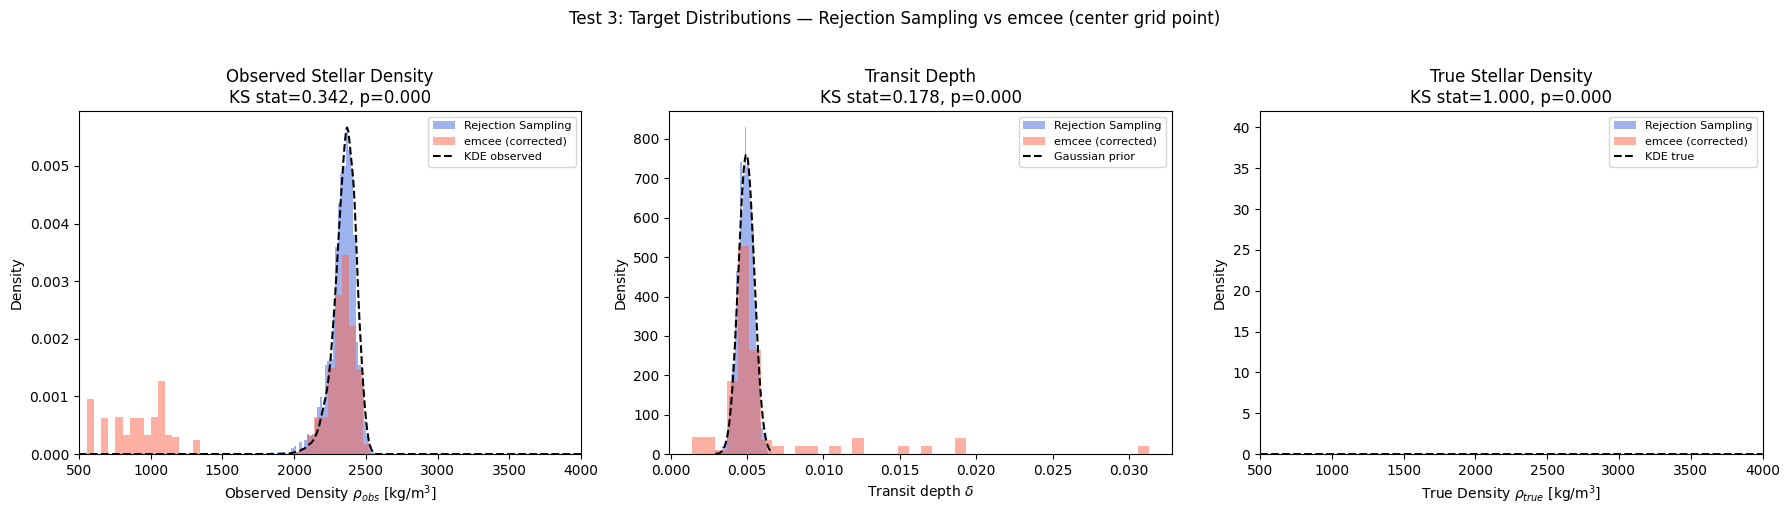

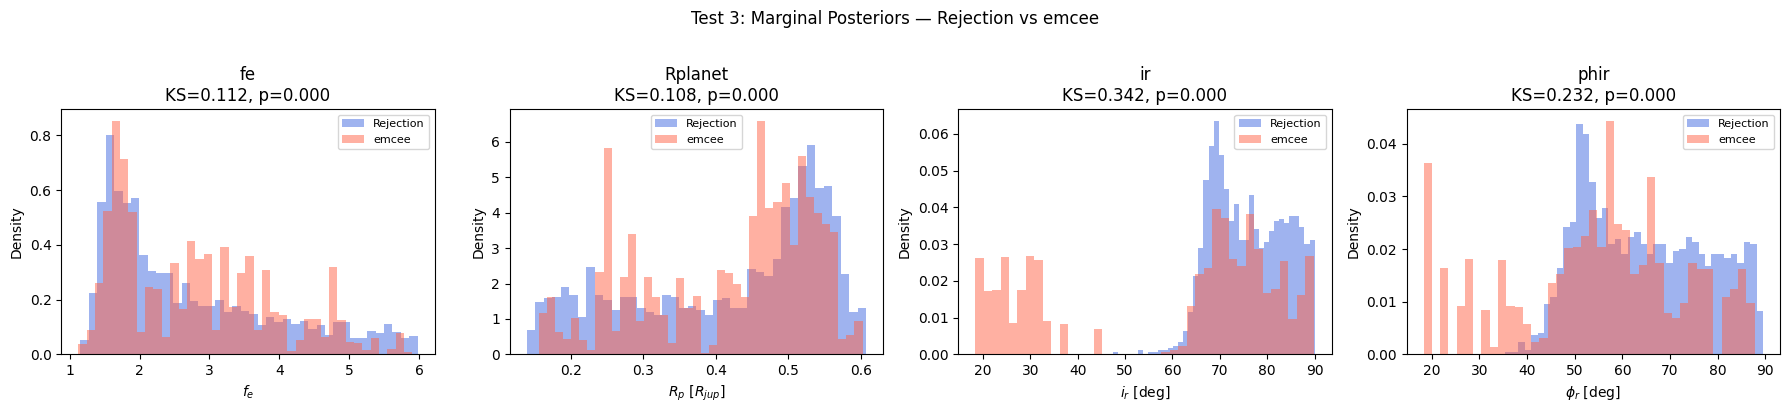


=== KS Test Summary (H0: same distribution) ===
Parameter       KS stat    p-value    H0 (α=0.05)
  rho_obs          0.3415     0.0000       REJECTED
  delta            0.1776     0.0000       REJECTED
  rho_true         1.0000     0.0000       REJECTED
  fe               0.1123     0.0000       REJECTED
  Rplanet          0.1079     0.0000       REJECTED
  ir               0.3415     0.0000       REJECTED
  phir             0.2319     0.0000       REJECTED

Acceptance fraction: 0.155 (ideal range: 0.20–0.50)


In [15]:
from scipy.stats import ks_2samp

# ── Plot 1: Target distributions ─────────────────────────────────────────
rho_range = (500, 4000)
fig1, axs = plt.subplots(1, 3, figsize=(18, 5))

# rho_obs
axs[0].hist(Xs_rej['rho_obs'], bins=40, density=True, alpha=0.5, color='royalblue', label='Rejection Sampling')
axs[0].hist(df_emcee['rho_obs'], bins=40, density=True, alpha=0.5, color='tomato', label='emcee (corrected)')
x = np.linspace(*rho_range, 400)
axs[0].plot(x, S3.rho_obs_fun(x), 'k--', lw=1.5, label='KDE observed')
ks_rho_obs = ks_2samp(Xs_rej['rho_obs'].dropna(), df_emcee['rho_obs'].dropna())
axs[0].set_xlim(*rho_range)
axs[0].set_xlabel(r'Observed Density $\rho_{obs}$ [kg/m$^3$]')
axs[0].set_ylabel('Density')
axs[0].set_title(f'Observed Stellar Density\nKS stat={ks_rho_obs.statistic:.3f}, p={ks_rho_obs.pvalue:.3f}')
axs[0].legend(fontsize=8)

# delta
axs[1].hist(Xs_rej['delta'], bins=40, density=True, alpha=0.5, color='royalblue', label='Rejection Sampling')
axs[1].hist(df_emcee['delta'], bins=40, density=True, alpha=0.5, color='tomato', label='emcee (corrected)')
delta_vals = np.linspace(Xs_rej['delta'].min(), Xs_rej['delta'].max(), 400)
axs[1].plot(delta_vals, S3.delta_fun(delta_vals), 'k--', lw=1.5, label='Gaussian prior')
ks_delta = ks_2samp(Xs_rej['delta'].dropna(), df_emcee['delta'].dropna())
axs[1].set_xlabel(r'Transit depth $\delta$')
axs[1].set_ylabel('Density')
axs[1].set_title(f'Transit Depth\nKS stat={ks_delta.statistic:.3f}, p={ks_delta.pvalue:.3f}')
axs[1].legend(fontsize=8)

# rho_true
axs[2].hist(Xs_rej['rho_true'], bins=40, density=True, alpha=0.5, color='royalblue', label='Rejection Sampling')
axs[2].hist(df_emcee['rho_true'], bins=40, density=True, alpha=0.5, color='tomato', label='emcee (corrected)')
axs[2].plot(x, S3.rho_true_fun(x), 'k--', lw=1.5, label='KDE true')
ks_rho_true = ks_2samp(Xs_rej['rho_true'].dropna(), df_emcee['rho_true'].dropna())
axs[2].set_xlim(*rho_range)
axs[2].set_xlabel(r'True Density $\rho_{true}$ [kg/m$^3$]')
axs[2].set_ylabel('Density')
axs[2].set_title(f'True Stellar Density\nKS stat={ks_rho_true.statistic:.3f}, p={ks_rho_true.pvalue:.3f}')
axs[2].legend(fontsize=8)

fig1.suptitle('Test 3: Target Distributions — Rejection Sampling vs emcee (center grid point)',
              fontsize=12, y=1.02)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/validation_test3_targets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Marginal posteriors ───────────────────────────────────────────
param_names = list(props.keys())
fig2, axes = plt.subplots(1, len(param_names), figsize=(18, 4))

for k, pname in enumerate(param_names):
    ax = axes[k]
    ks_p = ks_2samp(Xs_rej[pname].dropna(), df_emcee[pname].dropna())
    ax.hist(Xs_rej[pname], bins=40, density=True, alpha=0.5, color='royalblue', label='Rejection')
    ax.hist(df_emcee[pname], bins=40, density=True, alpha=0.5, color='tomato', label='emcee')
    ax.set_xlabel(props[pname]['label'])
    ax.set_ylabel('Density')
    ax.set_title(f'{pname}\nKS={ks_p.statistic:.3f}, p={ks_p.pvalue:.3f}')
    ax.legend(fontsize=8)

fig2.suptitle('Test 3: Marginal Posteriors — Rejection vs emcee',
              fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/validation_test3_marginals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── KS summary table ─────────────────────────────────────────────────────
print('\n=== KS Test Summary (H0: same distribution) ===')
print(f"{'Parameter':<12} {'KS stat':>10} {'p-value':>10} {'H0 (α=0.05)':>14}")
for name, res in [('rho_obs', ks_rho_obs), ('delta', ks_delta),
                  ('rho_true', ks_rho_true)] + \
                 [(p, ks_2samp(Xs_rej[p].dropna(), df_emcee[p].dropna())) for p in param_names]:
    verdict = 'NOT rejected' if res.pvalue > 0.05 else 'REJECTED'
    print(f'  {name:<12} {res.statistic:>10.4f} {res.pvalue:>10.4f} {verdict:>14}')

# ── Acceptance fraction summary ───────────────────────────────────────────
acc = np.mean(sampler3.acceptance_fraction)
print(f'\nAcceptance fraction: {acc:.3f} (ideal range: 0.20–0.50)')
if acc < 0.20:
    print('  WARNING: too low — consider reducing proposal scatter or checking log_prob')
elif acc > 0.50:
    print('  WARNING: too high — sampler may not be mixing well')
else:
    print('  OK: acceptance fraction within ideal range')


---
## Test 4: Convergence Diagnostics

TEST 4: Convergence Diagnostics
  nsteps=232, nwalkers=64, ndim=4
  burn_in=200
  τ (autocorr time): [nan nan nan nan]
  τ_max = nan  |  burn_in/τ_max = nan
  Convergence (burn_in > 2·τ_max): False


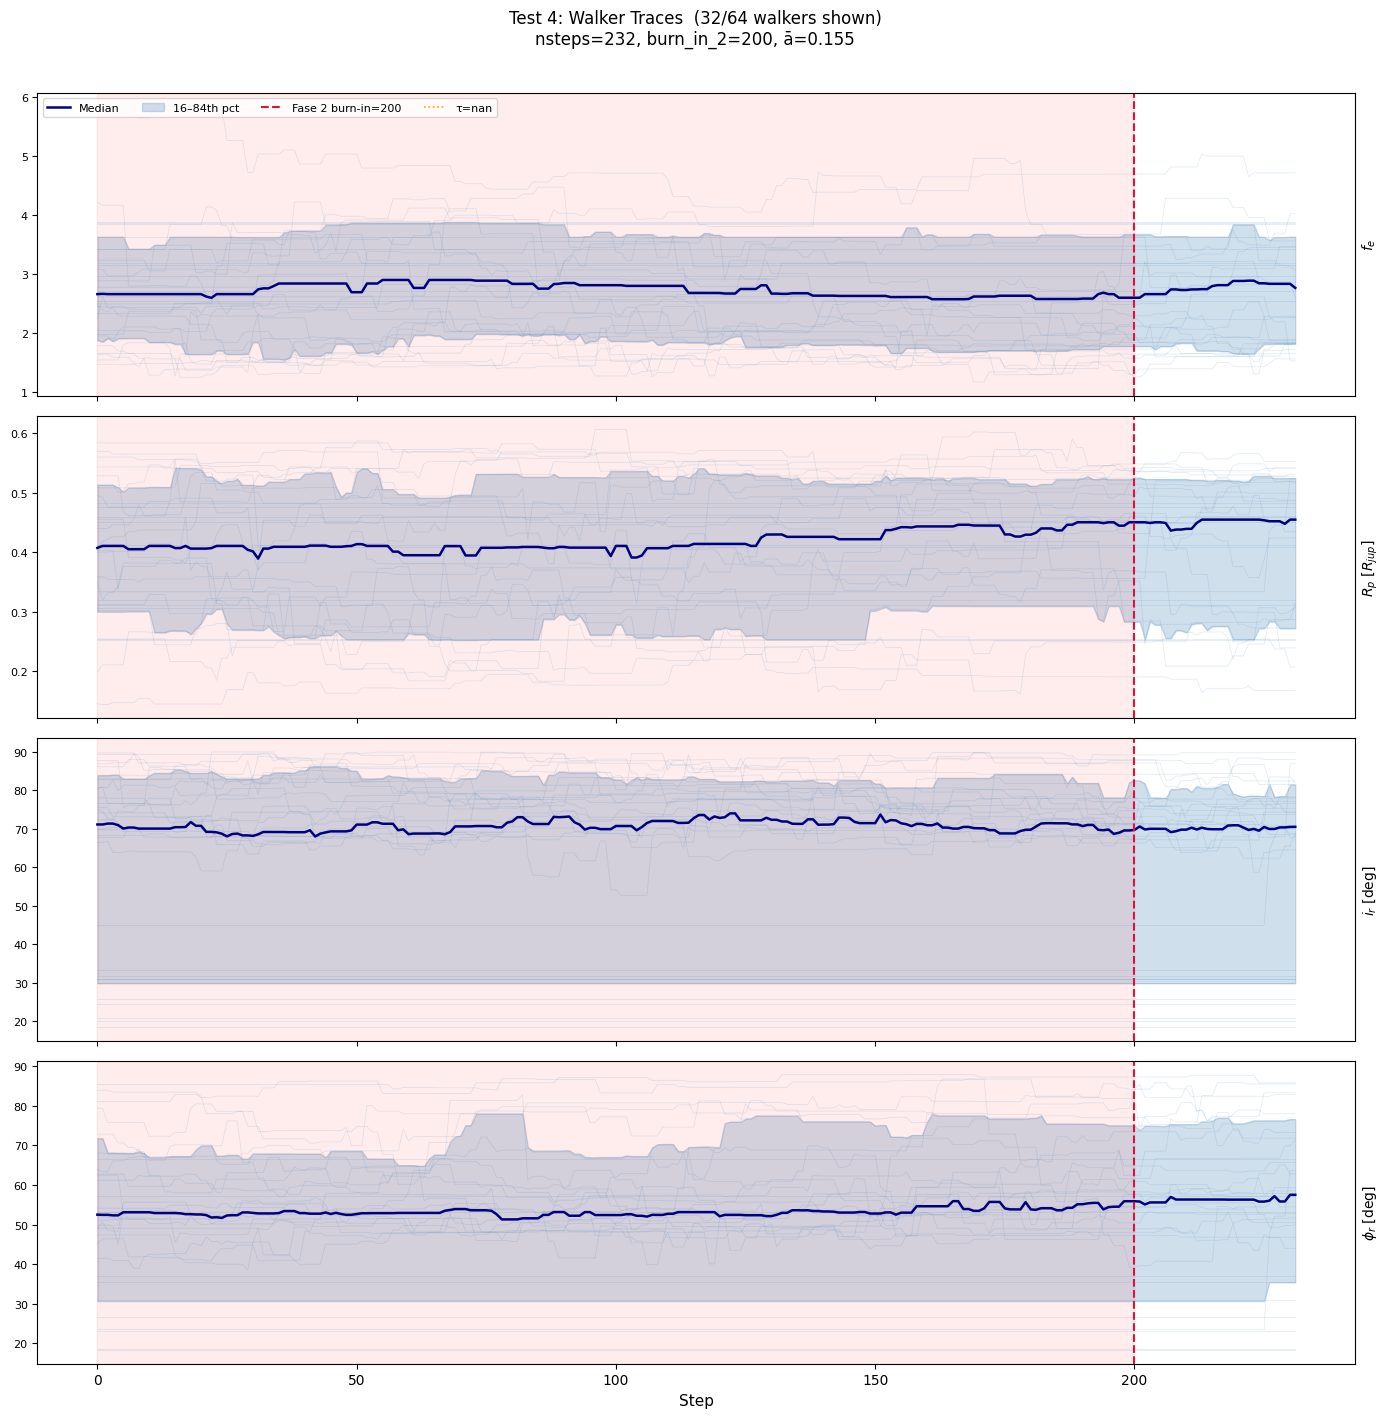

In [16]:
print('='*60)
print('TEST 4: Convergence Diagnostics')
print('='*60)

# Use sampler3 from Test 3 (same grid point, tuned hyperparams)
chain = sampler3.get_chain()  # shape: (nsteps, nwalkers, ndim)
nsteps_run, nw_run, _ = chain.shape

print(f'  nsteps={nsteps_run}, nwalkers={nw_run}, ndim={ndim}')
print(f'  burn_in={burn_in_2}')

# ── Autocorrelation time ──────────────────────────────────────────────────
try:
    tau_arr = sampler3.get_autocorr_time(quiet=True)
    print(f'  τ (autocorr time): {tau_arr.round(1)}')
    print(f'  τ_max = {tau_arr.max():.1f}  |  burn_in/τ_max = {burn_in_2/tau_arr.max():.1f}')
    converged = burn_in_2 > 2 * tau_arr.max()
    print(f'  Convergence (burn_in > 2·τ_max): {converged}')
except Exception as e:
    print(f'  Could not compute τ: {e}')
    tau_arr = None

# ── Trace plot — all walkers, alpha-blended ────────────────────────────────
# Show all walkers but with low alpha for individual traces;
# overlay the per-step median as a thick line for readability.
param_labels = [props[p]['label'] for p in param_names]

n_show = min(32, nw_run)   # show at most 32 walkers to avoid clutter
steps  = np.arange(nsteps_run)

fig, axes = plt.subplots(ndim, 1, figsize=(14, 3.5 * ndim), sharex=True)

for k in range(ndim):
    ax = axes[k]
    param_chain = chain[:, :n_show, k]          # (nsteps, n_show)

    # Individual walker traces (very transparent)
    for w in range(n_show):
        ax.plot(steps, param_chain[:, w], alpha=0.15, lw=0.6, color='steelblue')

    # Median trace across walkers (bold)
    median_trace = np.median(param_chain, axis=1)
    ax.plot(steps, median_trace, color='navy', lw=1.8, label='Median')

    # 16th–84th percentile band
    p16 = np.percentile(param_chain, 16, axis=1)
    p84 = np.percentile(param_chain, 84, axis=1)
    ax.fill_between(steps, p16, p84, alpha=0.25, color='steelblue', label='16–84th pct')

    # Burn-in marker
    ax.axvline(burn_in_2, color='crimson', ls='--', lw=1.5, label=f'Fase 2 burn-in={burn_in_2}')

    # Shade burn-in region
    ax.axvspan(0, burn_in_2, alpha=0.07, color='red')

    # τ annotation
    if tau_arr is not None:
        ax.axvline(tau_arr[k], color='orange', ls=':', lw=1.2, label=f'τ={tau_arr[k]:.0f}')

    ax.set_ylabel(param_labels[k], fontsize=10)
    ax.yaxis.set_label_position('right')
    ax.tick_params(axis='y', labelsize=8)
    if k == 0:
        ax.legend(fontsize=8, loc='upper left', ncol=4)

axes[-1].set_xlabel('Step', fontsize=11)
fig.suptitle(
    f'Test 4: Walker Traces  ({n_show}/{nw_run} walkers shown)\n'
    f'nsteps={nsteps_run}, burn_in_2={burn_in_2}, '
    f'ā={np.mean(sampler3.acceptance_fraction):.3f}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('figures/validation_test4_traces.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Test 5: Kolmogorov-Smirnov Test of Marginals

Test estadístico formal de si las distribuciones marginales son indistinguibles.

In [17]:
print('='*60)
print('TEST 5: Kolmogorov-Smirnov Test')
print('='*60)

alpha_threshold = 0.01  # significance level
all_ks_pass = True

for pname in param_names:
    stat, pval = ks_2samp(Xs_rej[pname].values, df_emcee[pname].values)
    passed = pval > alpha_threshold
    if not passed:
        all_ks_pass = False
    print(f'  {pname}: KS statistic = {stat:.4f}, p-value = {pval:.4f} '
          f'→ {"PASS" if passed else "FAIL (distributions differ)"}')

# Also test derived quantities
derived = ['rho_obs', 'delta', 'rho_true']
for dname in derived:
    if dname in Xs_rej.columns and dname in df_emcee.columns:
        s1 = Xs_rej[dname].dropna().values
        s2 = df_emcee[dname].dropna().values
        if len(s1) > 0 and len(s2) > 0:
            stat, pval = ks_2samp(s1, s2)
            passed = pval > alpha_threshold
            if not passed:
                all_ks_pass = False
            print(f'  {dname}: KS statistic = {stat:.4f}, p-value = {pval:.4f} '
                  f'→ {"PASS" if passed else "FAIL (distributions differ)"}')

print()
print(f'Overall KS Test Result: {"PASS" if all_ks_pass else "FAIL"}')
print()
if not all_ks_pass:
    print('NOTE: KS test failure may indicate:')
    print('  (a) The emcee chain is not long enough')
    print('  (b) Burn-in is insufficient')
    print('  (c) Sample sizes are too small for convergence')
    print('  Try increasing Np_test, nsteps, or burn_in.')

TEST 5: Kolmogorov-Smirnov Test
  fe: KS statistic = 0.1123, p-value = 0.0000 → FAIL (distributions differ)
  Rplanet: KS statistic = 0.1079, p-value = 0.0000 → FAIL (distributions differ)
  ir: KS statistic = 0.3415, p-value = 0.0000 → FAIL (distributions differ)
  phir: KS statistic = 0.2319, p-value = 0.0000 → FAIL (distributions differ)
  rho_obs: KS statistic = 0.3415, p-value = 0.0000 → FAIL (distributions differ)
  delta: KS statistic = 0.1776, p-value = 0.0000 → FAIL (distributions differ)
  rho_true: KS statistic = 1.0000, p-value = 0.0000 → FAIL (distributions differ)

Overall KS Test Result: FAIL

NOTE: KS test failure may indicate:
  (a) The emcee chain is not long enough
  (b) Burn-in is insufficient
  (c) Sample sizes are too small for convergence
  Try increasing Np_test, nsteps, or burn_in.


---
## Summary

In [18]:
print('='*60)
print('VALIDATION SUMMARY')
print('='*60)
print()
print('Test 1 (Likelihood equivalence):       ', 'PASS' if all_pass else 'FAIL')
print('Test 2 (nsteps formula diagnosis):      ', 'BUG CONFIRMED' if any_bad else 'OK')
print('Test 3 (Visual posterior comparison):    See plots above')
print('Test 4 (Convergence diagnostics):       ', 
      'PASS' if is_af_ok else 'FAIL')
print('Test 5 (KS test of marginals):          ', 'PASS' if all_ks_pass else 'FAIL')
print()
print('RECOMMENDED FIX for mcra-planet-b_emcee.ipynb:')
print('  Replace line:')
print('    nsteps = max(50, int(Np / (nwalkers * (1 - burn_in/nsteps_per_grid))))')
print('  With:')
print('    nsteps = max(2 * burn_in, burn_in + int(np.ceil(Np / nwalkers)))')
print()
print('  This ensures the full burn_in period is always respected.')

VALIDATION SUMMARY

Test 1 (Likelihood equivalence):        PASS
Test 2 (nsteps formula diagnosis):       OK
Test 3 (Visual posterior comparison):    See plots above


NameError: name 'is_af_ok' is not defined